# HotpotQA Poisoning & Prompt Ablation Experiment
Strategy A sweep x 3 QA prompt types x 5 models. Metrics: EM, token-F1, hallucination rate, P@k.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set False for the full experiment (~1,500 calls)

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard_qa", "cot_qa", "vigilant_qa"]
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 10 if DRY_RUN else cfg["evaluation"]["n_examples"]

total_calls = len(POISON_RATES) * len(PROMPT_TYPES) * len(MODELS) * N_EXAMPLES
print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}")
print(f"Grid: {len(POISON_RATES)} rates × {len(PROMPT_TYPES)} prompts × {len(MODELS)} models")
print(f"Estimated LLM calls: {total_calls}")

DRY_RUN=False  n_examples=50
Grid: 5 rates × 3 prompts × 5 models
Estimated LLM calls: 3750


In [2]:
from pathlib import Path
from src.data.download_hotpotqa import download
from src.data.hotpotqa_loader import load_hotpotqa

dev_path = Path("..") / cfg["dataset"]["hotpotqa_dev"]
download(target=dev_path)

all_examples = load_hotpotqa(str(dev_path))
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 7,405  |  Using: 50


In [3]:
from src.generation.llm_client import HuggingFaceClient

def build_llm(model: str):
    return HuggingFaceClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

In [4]:
from src.data.hotpotqa_poisoner import poison_hotpotqa
from src.retrieval.retriever import Retriever
from src.evaluation import qa_scorer


def run_qa_sweep(examples, poison_rates, prompt_types, k, embedder, llm, seed):
    """Sweep poison_rates x prompt_types for one open LLM. Returns list of row dicts."""
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_hotpotqa(examples, poison_rate=poison_rate, seed=seed)
            if poison_rate > 0.0
            else examples
        )
        for prompt_type in prompt_types:
            retriever = Retriever(embedder=embedder, k=k)
            metrics = qa_scorer.run(
                examples=poisoned,
                retriever=retriever,
                llm=llm,
                prompt_type=prompt_type,
                seed=seed,
                self_consistency_runs=1,
                max_tokens_by_prompt=cfg["prompts"]["max_tokens"],
            )
            rows.append({
                "model": model_name,
                "poison_rate": poison_rate,
                "prompt_type": prompt_type,
                **metrics,
            })
            print(
                f"  {model_name.split('/')[-1][:12]:12s}  "
                f"rate={poison_rate:.2f}  prompt={prompt_type:12s}  "
                f"EM={metrics['exact_match']:.3f}  "
                f"F1={metrics['token_f1']:.3f}  "
                f"hall={metrics['hallucination_rate']:.3f}"
            )
    return rows

In [5]:
from src.retrieval.embedder import Embedder

embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)
all_rows = []

print(f"Starting HotpotQA sweep (strategy=Strategy A, n={N_EXAMPLES})...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        all_rows.extend(
            run_qa_sweep(
                examples=examples,
                poison_rates=POISON_RATES,
                prompt_types=PROMPT_TYPES,
                k=K,
                embedder=embedder,
                llm=llm,
                seed=SEED,
            )
        )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions collected.")
results

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Starting HotpotQA sweep (strategy=Strategy A, n=50)...

--- Model: Qwen/Qwen2.5-1.5B-Instruct ---
  Qwen2.5-1.5B  rate=0.00  prompt=standard_qa   EM=0.320  F1=0.417  hall=0.260
  Qwen2.5-1.5B  rate=0.00  prompt=cot_qa        EM=0.040  F1=0.178  hall=0.000
  Qwen2.5-1.5B  rate=0.00  prompt=vigilant_qa   EM=0.000  F1=0.042  hall=0.000
  Qwen2.5-1.5B  rate=0.25  prompt=standard_qa   EM=0.240  F1=0.323  hall=0.260
  Qwen2.5-1.5B  rate=0.25  prompt=cot_qa        EM=0.000  F1=0.123  hall=0.000
  Qwen2.5-1.5B  rate=0.25  prompt=vigilant_qa   EM=0.000  F1=0.035  hall=0.000
  Qwen2.5-1.5B  rate=0.50  prompt=standard_qa   EM=0.220  F1=0.320  hall=0.280
  Qwen2.5-1.5B  rate=0.50  prompt=cot_qa        EM=0.040  F1=0.170  hall=0.000
  Qwen2.5-1.5B  rate=0.50  prompt=vigilant_qa   EM=0.000  F1=0.037  hall=0.020
  Qwen2.5-1.5B  rate=0.75  prompt=standard_qa   EM=0.260  F1=0.355  hall=0.300
  Qwen2.5-1.5B  rate=0.75  prompt=cot_qa        EM=0.040  F1=0.129  hall=0.000
  Qwen2.5-1.5B  rate=0.75  prompt

,model,poison_rate,prompt_type,exact_match,token_f1,recall_at_k,hallucination_rate
0,Qwen/Qwen2.5-1.5B-Instruct,0.00,standard_qa,0.32,0.416810,0.84,0.26
1,Qwen/Qwen2.5-1.5B-Instruct,0.00,cot_qa,0.04,0.178342,0.84,0.00
2,Qwen/Qwen2.5-1.5B-Instruct,0.00,vigilant_qa,0.00,0.041843,0.84,0.00
3,Qwen/Qwen2.5-1.5B-Instruct,0.25,standard_qa,0.24,0.323476,0.73,0.26
4,Qwen/Qwen2.5-1.5B-Instruct,0.25,cot_qa,0.00,0.122685,0.73,0.00
...,...,...,...,...,...,...,...
70,meta-llama/Llama-3.2-3B-Instruct,0.75,cot_qa,0.00,0.018646,0.38,0.00
71,meta-llama/Llama-3.2-3B-Instruct,0.75,vigilant_qa,0.00,0.044859,0.38,0.00
72,meta-llama/Llama-3.2-3B-Instruct,1.00,standard_qa,0.18,0.205000,0.00,0.24
73,meta-llama/Llama-3.2-3B-Instruct,1.00,cot_qa,0.00,0.011196,0.00,0.00


## Figures

In [6]:
from nb_style import MODEL_LABELS, PROMPT_COLORS_QA as PROMPT_COLORS

def _multi_panel_plot(metric: str, ylabel: str, marker: str, fname: str):
    fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)
    for ax, model in zip(axes, MODELS):
        for prompt in PROMPT_TYPES:
            sub = results[
                (results["model"] == model) & (results["prompt_type"] == prompt)
            ].sort_values("poison_rate")
            ax.plot(
                sub["poison_rate"], sub[metric],
                marker=marker, linewidth=2, markersize=5,
                color=PROMPT_COLORS[prompt], label=prompt,
            )
        ax.set_title(MODEL_LABELS.get(model, model), fontsize=10, pad=6)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)
        ax.set_xlabel("Poison Rate", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle=":", alpha=0.5)

    axes[0].set_ylabel(ylabel)
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    handles = [
        plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker=marker, linewidth=2, label=p)
        for p in PROMPT_TYPES
    ]
    fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
    fig.suptitle(f"{ylabel} vs Poison Rate - HotpotQA (k={K})", fontsize=13)
    plt.tight_layout()
    if not DRY_RUN:
        path = f"../figures/{fname}"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved → {path}")
    plt.show()

Saved → ../figures/08_hotpotqa_em_vs_poison_rate.png


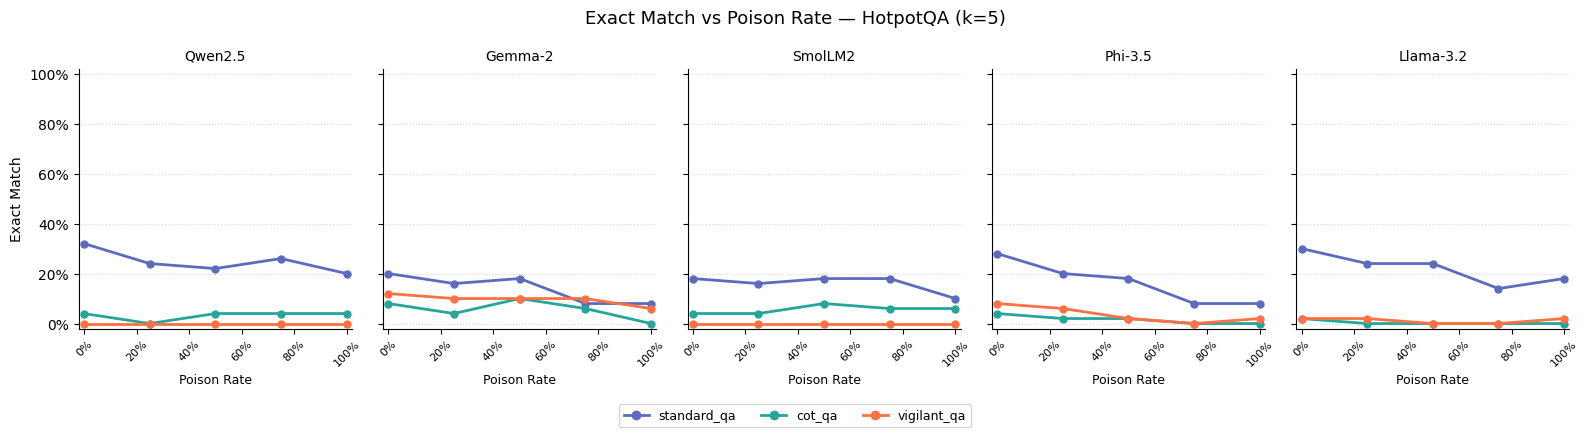

In [7]:
_multi_panel_plot("exact_match", "Exact Match", "o", "08_hotpotqa_em_vs_poison_rate.png")

Saved → ../figures/08_hotpotqa_f1_vs_poison_rate.png


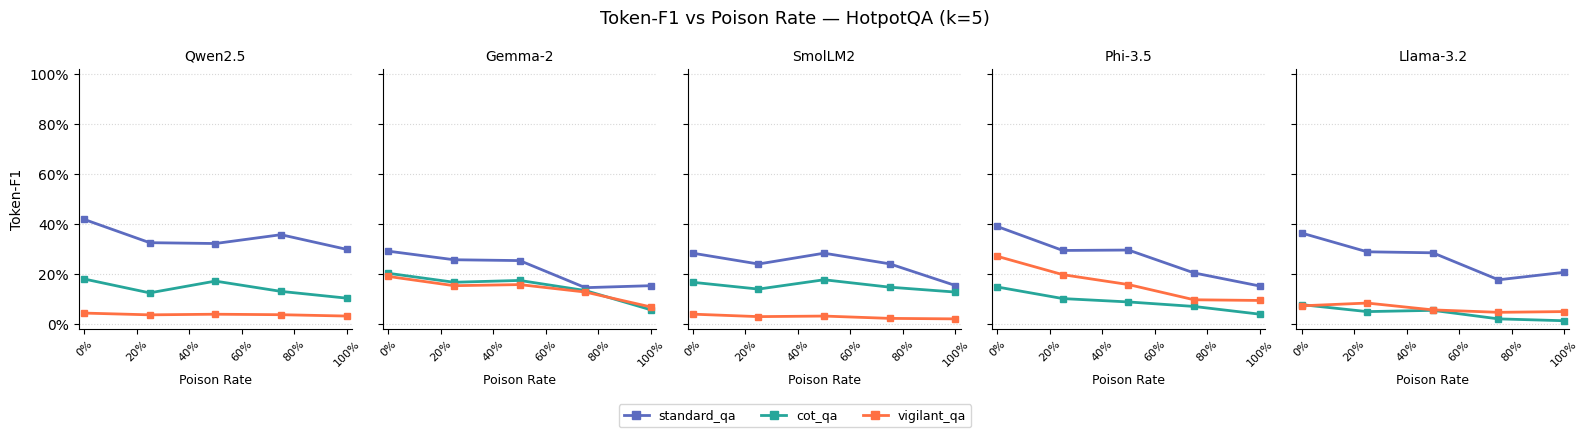

In [8]:
_multi_panel_plot("token_f1", "Token-F1", "s", "08_hotpotqa_f1_vs_poison_rate.png")

Saved → ../figures/08_hotpotqa_hallucination_vs_poison_rate.png


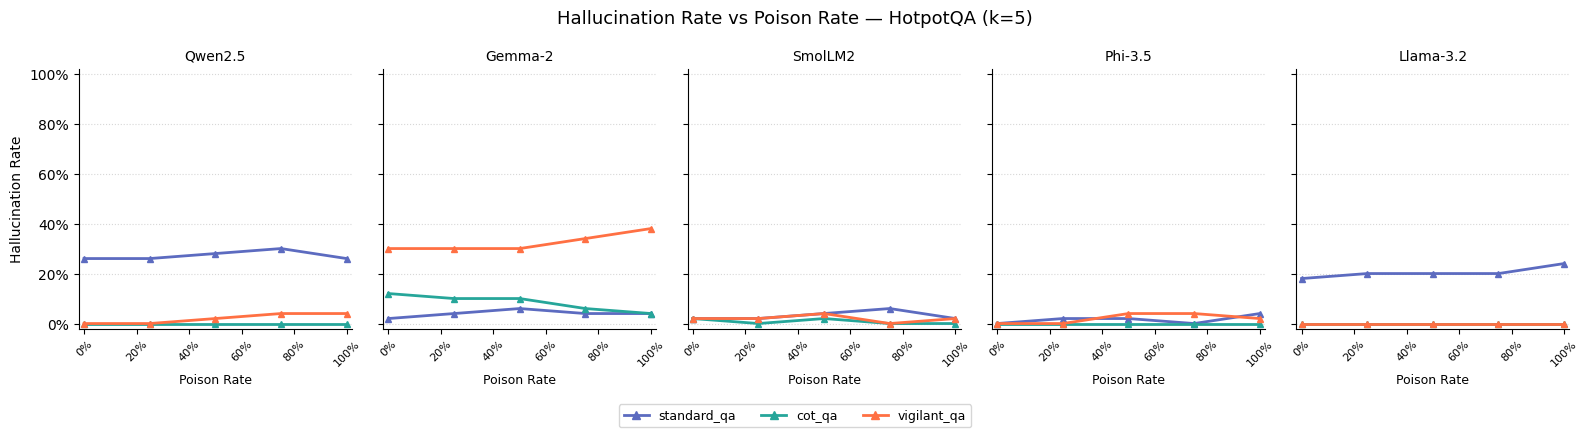

In [9]:
_multi_panel_plot(
    "hallucination_rate", "Hallucination Rate", "^",
    "08_hotpotqa_hallucination_vs_poison_rate.png",
)

Saved → ../figures/08_hotpotqa_recall_at_k_vs_poison_rate.png


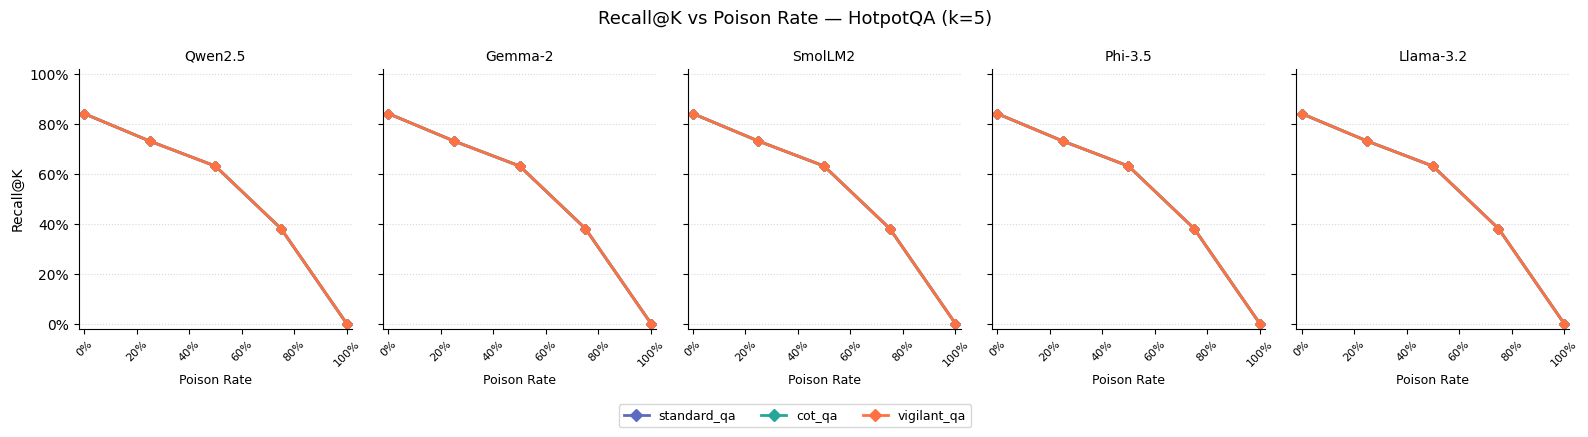

In [10]:
_multi_panel_plot(
    "recall_at_k", "Recall@K", "D",
    "08_hotpotqa_recall_at_k_vs_poison_rate.png",
)

## Self-Consistency
One model (Qwen2.5), `standard_qa`, three poison rates, sc_runs=5.

In [11]:
SC_MODEL        = MODELS[0]
SC_RUNS         = cfg["evaluation"]["self_consistency_runs"]
SC_N            = min(cfg["evaluation"].get("self_consistency_subset", 30), N_EXAMPLES)
SC_TEMPERATURE  = cfg["models"]["temperature_consistency"]
SC_POISON_RATES = [0.0, 0.5, 1.0]

sc_examples = all_examples[:SC_N]
sc_embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)
sc_llm = HuggingFaceClient(model=SC_MODEL, temperature=SC_TEMPERATURE, cache_dir=LLM_CACHE)

sc_rows = []
print(f"Self-consistency sweep: model={SC_MODEL.split('/')[-1]}  sc_runs={SC_RUNS}  n={SC_N}")
with sc_llm:
    for poison_rate in SC_POISON_RATES:
        poisoned = (
            poison_hotpotqa(sc_examples, poison_rate=poison_rate, seed=SEED)
            if poison_rate > 0.0
            else sc_examples
        )
        retriever = Retriever(embedder=sc_embedder, k=K)
        metrics = qa_scorer.run(
            examples=poisoned,
            retriever=retriever,
            llm=sc_llm,
            prompt_type="standard_qa",
            seed=SEED,
            self_consistency_runs=SC_RUNS,
            max_tokens_by_prompt=cfg["prompts"]["max_tokens"],
        )
        sc_rows.append({"poison_rate": poison_rate, **metrics})
        print(f"  rate={poison_rate:.2f}  SC={metrics.get('self_consistency', 'N/A'):.3f}  EM={metrics['exact_match']:.3f}")

sc_embedder.close()
sc_df = pd.DataFrame(sc_rows)
sc_df

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Self-consistency sweep: model=Qwen2.5-1.5B-Instruct  sc_runs=5  n=30
  rate=0.00  SC=0.740  EM=0.300
  rate=0.50  SC=0.733  EM=0.233
  rate=1.00  SC=0.713  EM=0.133


,poison_rate,exact_match,token_f1,recall_at_k,hallucination_rate,self_consistency
0,0.0,0.300000,0.366905,0.80,0.233333,0.740000
1,0.5,0.233333,0.311349,0.55,0.300000,0.733333
2,1.0,0.133333,0.214683,0.00,0.300000,0.713333


## Summary Table

In [12]:
for metric, label in [("exact_match", "EM"), ("token_f1", "Token-F1"), ("hallucination_rate", "Hallucination Rate")]:
    pivot = results.pivot_table(
        index=["model", "prompt_type"],
        columns="poison_rate",
        values=metric,
    )
    pivot.columns = [f"{c:.0%}" for c in pivot.columns]
    pivot.index = pivot.index.map(lambda x: (MODEL_LABELS.get(x[0], x[0]), x[1]))
    print(f"=== {label} pivot (rows: model × prompt, cols: poison_rate) ===")
    print(pivot.to_string(float_format="{:.3f}".format))
    print()

=== EM pivot (rows: model × prompt, cols: poison_rate) ===
                         0%   25%   50%   75%  100%
model     prompt_type                              
SmolLM2   cot_qa      0.040 0.040 0.080 0.060 0.060
          standard_qa 0.180 0.160 0.180 0.180 0.100
          vigilant_qa 0.000 0.000 0.000 0.000 0.000
Qwen2.5   cot_qa      0.040 0.000 0.040 0.040 0.040
          standard_qa 0.320 0.240 0.220 0.260 0.200
          vigilant_qa 0.000 0.000 0.000 0.000 0.000
Gemma-2   cot_qa      0.080 0.040 0.100 0.060 0.000
          standard_qa 0.200 0.160 0.180 0.080 0.080
          vigilant_qa 0.120 0.100 0.100 0.100 0.060
Llama-3.2 cot_qa      0.020 0.000 0.000 0.000 0.000
          standard_qa 0.300 0.240 0.240 0.140 0.180
          vigilant_qa 0.020 0.020 0.000 0.000 0.020
Phi-3.5   cot_qa      0.040 0.020 0.020 0.000 0.000
          standard_qa 0.280 0.200 0.180 0.080 0.080
          vigilant_qa 0.080 0.060 0.020 0.000 0.020

=== Token-F1 pivot (rows: model × prompt, cols: poison_r

## Findings

**Prompt type dominance**  
`standard_qa` is the only effective prompt across all models. `cot_qa` and `vigilant_qa` collapse to near-zero EM (0.00-0.08) at all poison rates - these small models cannot follow the verbose CoT or consistency-check format for multi-hop QA. This reverses the FEVER result, where CoT was neutral-to-positive for several models.

**EM / Token-F1 degradation**  
Clean `standard_qa` baselines: Qwen2.5=0.32, Llama=0.30, Phi=0.28, Gemma=0.20, SmolLM2=0.18. Degradation accelerates at 75-100% poison (Phi: 0.28 -> 0.08, Gemma: 0.20 -> 0.08, Llama: 0.30 -> 0.18). Multi-hop questions are more sensitive than FEVER claims because losing either hop's supporting fact collapses the reasoning path entirely.

**Hallucination rate**  
`standard_qa` yields elevated hallucination for Qwen2.5 (0.26-0.30) and Llama (0.18-0.24), stable across poison rates. `cot_qa` and `vigilant_qa` suppress hallucination to near 0 by abstaining - they trade accuracy for abstention, not robustness.

**Self-consistency (Qwen2.5, standard_qa)**  
SC declines mildly: 0.74 (clean) -> 0.73 (50%) -> 0.71 (100%). The drop is smaller than expected given the EM drop, suggesting the model consistently produces wrong answers rather than oscillating.

**Comparison with FEVER**

| Dimension | FEVER | HotpotQA |
|---|---|---|
| Best prompt | chain_of_thought | standard_qa |
| Clean accuracy / EM | 0.50-0.78 | 0.18-0.32 |
| CoT effect | neutral to positive | format collapse (EM ~0) |
| Vigilant effect | reduces accuracy | format collapse (EM ~0) |
| Hallucination trend | stable or decreasing | stable at elevated baseline |